In [6]:
import sys
sys.path.insert(1, '/home/bricej/MyPythonLibrary/StageM2_IVT/library/')
from domain import *
import geopandas as gpd
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
from shapely.geometry import Polygon, MultiPolygon
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
from matplotlib.patches import Patch

# Elevation data

In [3]:
elev = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/bricej/gmted/gmted_on_era5_MA.nc')['elevation']

# Glacier area data

Glacier area data is from RGIv7.0 (Data set id: NSIDC-0770, DOI: 10.5067/F6JMOVY5NAVZ). The region corresponding to High Mountain Asia correspond to the regions 13, 14 & 15 of RGIv7.0 regions available. The data can be download from : 

https://daacdata.apps.nsidc.org/pub/DATASETS/nsidc0770_rgi_v7/regional_files/RGI2000-v7.0-G/ <br>
RGI2000-v7.0-G-13_central_asia.zip<br>
RGI2000-v7.0-G-14_south_asia_west.zip<br>
RGI2000-v7.0-G-15_south_asia_east.zip<br>



The different files were donwloaded in : 

/bettik/PROJECTS/pr-regional-climate/bricej/glacierized_areas/<br>
RGI2000-v7.0-G-13_central_asia/<br>
RGI2000-v7.0-G-14_south_asia_west/<br>
RGI2000-v7.0-G-15_south_asia_east/<br>

In [4]:
# Central Asia glaciers
glacier13 = gpd.read_file('/bettik/PROJECTS/pr-regional-climate/bricej/glacierized_areas/RGI2000-v7.0-G-13_central_asia/RGI2000-v7.0-G-13_central_asia.shp')

# South West Asia glaciers
glacier14 = gpd.read_file('/bettik/PROJECTS/pr-regional-climate/bricej/glacierized_areas/RGI2000-v7.0-G-14_south_asia_west/RGI2000-v7.0-G-14_south_asia_west.shp')

# South East Asia glaciers
glacier15 = gpd.read_file('/bettik/PROJECTS/pr-regional-climate/bricej/glacierized_areas/RGI2000-v7.0-G-15_south_asia_east/RGI2000-v7.0-G-15_south_asia_east.shp')


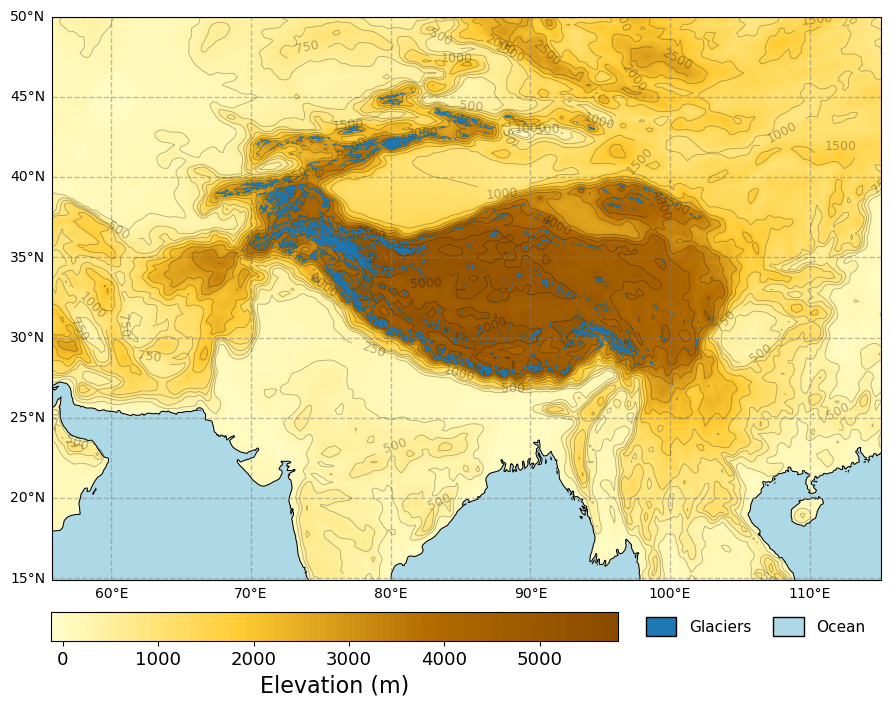

In [18]:
# colors for elevation on land
cmap = mcolors.LinearSegmentedColormap.from_list(
    "yellow_brown",
    ["#ffffcc",  # jaune très clair
     "#ffcc33",  # jaune doré
     "#b36b00",  # brun orangé
     "#8a4a00"]  # brun relativement clair
)

#figure
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# glacierized area
glacier13.plot(ax=ax,color = "tab:blue",edgecolor="tab:blue",linewidth=0.2,alpha=0.9,zorder=20)
glacier14.plot(ax=ax,color = "tab:blue",edgecolor="tab:blue",linewidth=0.2,alpha=0.9,zorder=20)
glacier15.plot(ax=ax,color = "tab:blue",edgecolor="tab:blue",linewidth=0.2,alpha=0.9,zorder=20)

ax.coastlines(linewidth=1.5) # coastline
ax.add_feature(cfeature.OCEAN, facecolor="lightblue", zorder=2) # ocean in blue
ax.add_feature(cfeature.LAND,facecolor="none", zorder=2) # land with no color

# evelvation with colorgrading
cf = ax.contourf(elev.longitude,elev.latitude,elev,levels=100,cmap=cmap,transform=ccrs.PlateCarree(),zorder=1)

# courbes de niveau
SH = ax.contour(elev.longitude,elev.latitude,elev,levels=[250,500,750,1000,1500,2000,2500,3000,3500,4000,4500,5000,5500,6000,6500,7000],
                colors="black",linewidths=0.6,alpha=0.3,transform=ccrs.PlateCarree(), zorder=3)
ax.clabel(SH, inline=True, fontsize=9, fmt="%d")

# color bar for elevation colorgrading
cbar = fig.colorbar(cf,ax=ax,orientation="horizontal",fraction=0.046,pad=0.04) # colorbar
pos = cbar.ax.get_position() # position de la colorbar
cbar.ax.set_position([
    pos.x0 - 0.11,  # gauche
    pos.y0 - 0.01,  # bas
    pos.width,pos.height])
cbar.set_label("Elevation (m)", fontsize=16)
cbar.set_ticks(list(range(0, 6000, 1000))) # forcer les ticks tous les 1000 de 0 à 6000 m
cbar.ax.tick_params(labelsize=13)

# Légende des glaciers à droite de la colorbar
ocean_patch = Patch(facecolor="tab:blue", edgecolor="black", label="Glaciers")
leg1 = cbar.ax.legend(handles=[ocean_patch],loc="center left",
               bbox_to_anchor=(1.025, 0.5), # à droite de la colorbar
               handlelength=2,handleheight=1.5,fontsize=11,frameon=False)
cbar.ax.add_artist(leg1)   # conserve la première légende

# Légende de l'océan à droite de la colorbar et glaciers
ocean_patch = Patch(facecolor="lightblue", edgecolor="black", label="Ocean")
cbar.ax.legend(handles=[ocean_patch],loc="center left",
               bbox_to_anchor=(1.25, 0.5), # à droite de la colorbar
               handlelength=2,handleheight=1.5,fontsize=11,frameon=False)

# extend limites de la figure
dg = gpd.read_file('/bettik/PROJECTS/pr-regional-climate/bricej/HIMAP_grouped_regions/himap_grouped_regions.shp')
bounds = dg.total_bounds #[minx, miny, maxx, maxy]
ax.set_extent([bounds[0]-11, bounds[2]+10.1, bounds[1]-10.7, bounds[3]+4],crs=ccrs.PlateCarree())

# grille lat lon
gl = ax.gridlines(draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

plt.show()

# Final plot

To make it easier to eddit, the figure was then addited with Canva to add the regional names & the two main atmospheric circulation patterns of the region. Here is the figure in .jpg :

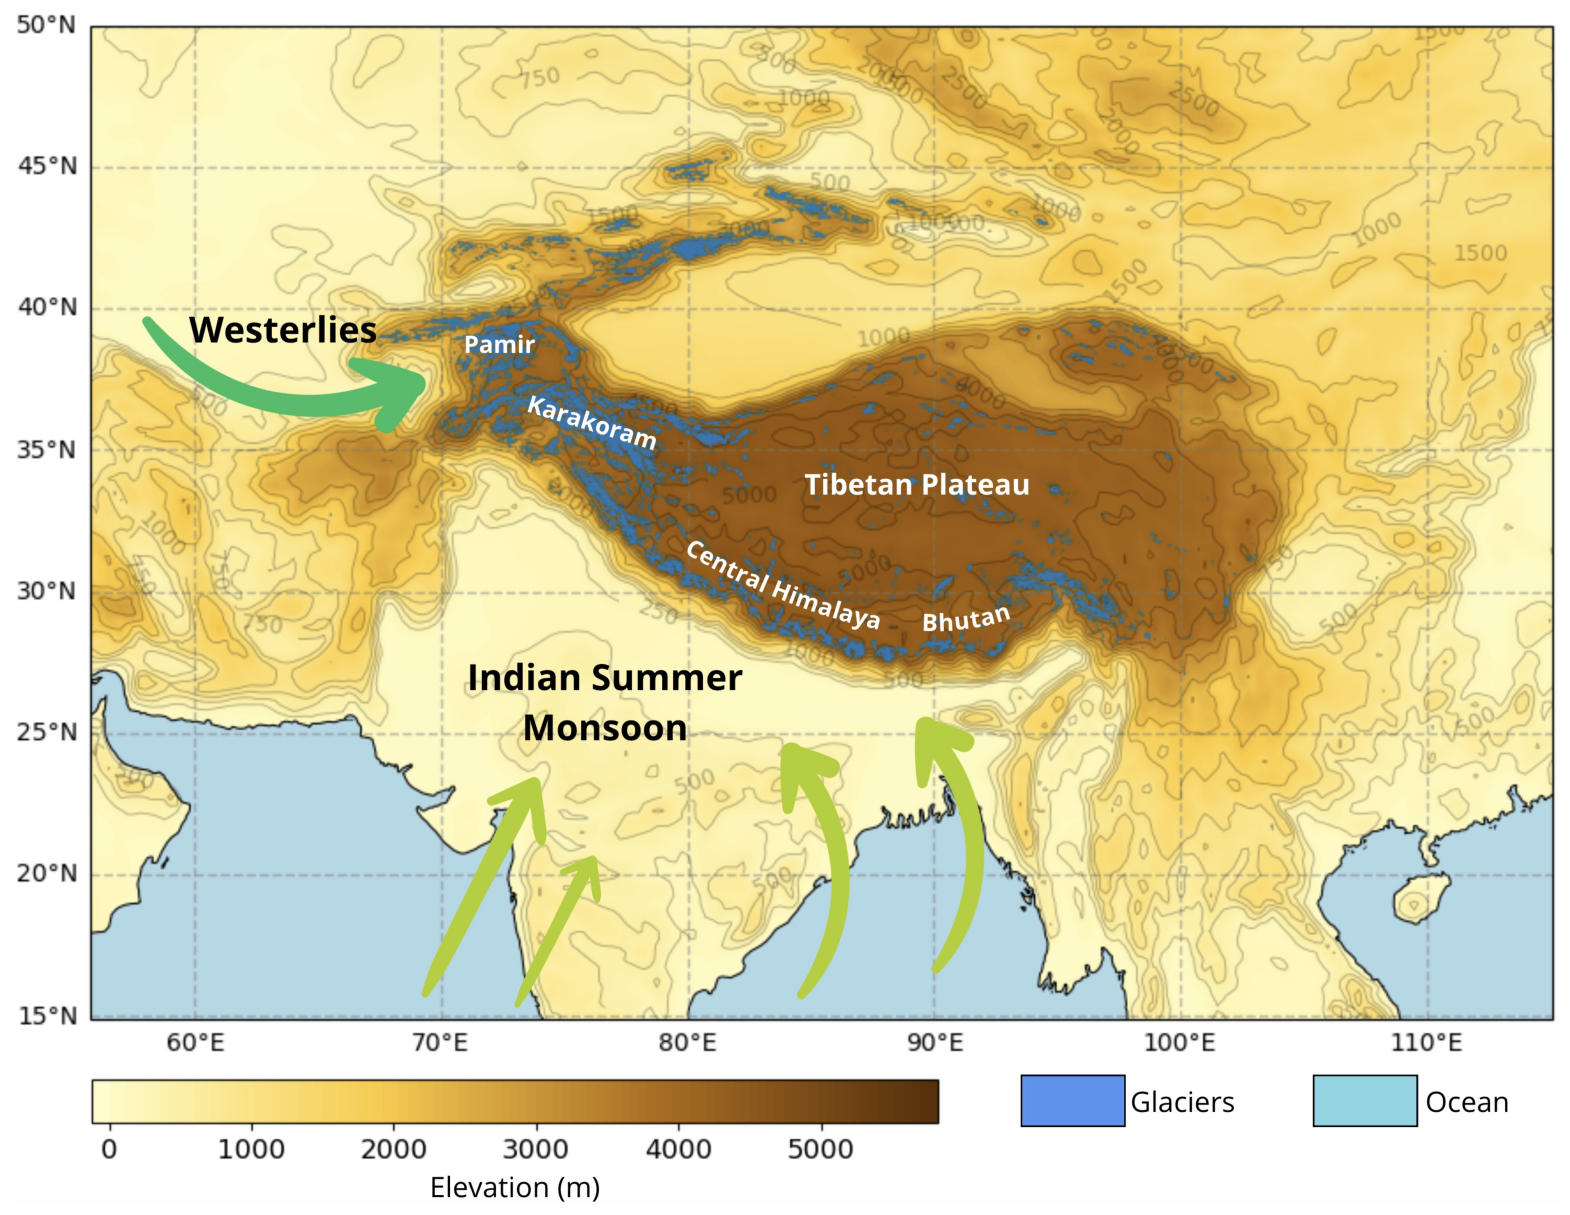

In [19]:
import matplotlib.image as mpimg # pour ouvrir l'image

# charger le fichier .jpg
image = mpimg.imread('/bettik/PROJECTS/pr-regional-climate/bricej/paper/fig_spatial-climatological_context_HMA.jpg')

# figure
plt.figure(figsize=(20, 18))
plt.imshow(image)
plt.axis("off")
plt.show()